# **Basic Setup (Installs, Imports, GPU Device)**

In [1]:
# Environment setup

!pip install -q scikit-learn

import time
import math
import random
from typing import Dict, List, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

import torchvision
import torchvision.transforms as T
from torchvision.models import resnet18, ResNet18_Weights

import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    precision_recall_fscore_support,
    accuracy_score,
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# **CIFAR-10 (Dataset, Transforms, DataLoaders)**

In [2]:
# CIFAR-10 datasets and dataloaders

CIFAR_ROOT = "./data"
NUM_CLASSES = 10
BATCH_SIZE_VIT = 128
BATCH_SIZE_HYBRID = 128
BATCH_SIZE_RESNET = 64

cifar_classes = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Transforms for ViT and Hybrid (32x32, CIFAR normalization)
transform_train_32 = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465),
                (0.2470, 0.2435, 0.2616)),
])

transform_test_32 = T.Compose([
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465),
                (0.2470, 0.2435, 0.2616)),
])

# Transforms for ResNet (ImageNet normalization and resizing)
resnet_weights = ResNet18_Weights.IMAGENET1K_V1
transform_train_resnet = resnet_weights.transforms(antialias=True)
transform_test_resnet = resnet_weights.transforms(antialias=True)

# Base CIFAR-10 downloads
train_dataset_raw = torchvision.datasets.CIFAR10(
    root=CIFAR_ROOT, train=True, download=True, transform=None
)
test_dataset_raw = torchvision.datasets.CIFAR10(
    root=CIFAR_ROOT, train=False, download=False, transform=None
)

# Helper to wrap CIFAR-10 raw dataset with a transform
class CIFAR10WithTransform(torch.utils.data.Dataset):
    """
    Wrapper dataset that applies a given transform to raw CIFAR-10 images.
    """
    def __init__(self, base_dataset, indices, transform):
        self.base = base_dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, label = self.base.data[real_idx], self.base.targets[real_idx]
        img = torchvision.transforms.functional.to_pil_image(img)
        img = self.transform(img)
        return img, label

# Train/val split indices (shared for all models)
num_train = len(train_dataset_raw)
val_size = 5000
train_size = num_train - val_size
all_indices = list(range(num_train))
random.shuffle(all_indices)
train_indices = all_indices[:train_size]
val_indices = all_indices[train_size:]

# Test indices (all)
test_indices = list(range(len(test_dataset_raw)))

# Datasets for ViT and Hybrid
train_dataset_32 = CIFAR10WithTransform(train_dataset_raw, train_indices, transform_train_32)
val_dataset_32   = CIFAR10WithTransform(train_dataset_raw, val_indices,   transform_test_32)
test_dataset_32  = CIFAR10WithTransform(test_dataset_raw,  test_indices,  transform_test_32)

# Datasets for ResNet
train_dataset_resnet = CIFAR10WithTransform(train_dataset_raw, train_indices, transform_train_resnet)
val_dataset_resnet   = CIFAR10WithTransform(train_dataset_raw, val_indices,   transform_test_resnet)
test_dataset_resnet  = CIFAR10WithTransform(test_dataset_raw,  test_indices,  transform_test_resnet)

# DataLoaders
train_loader_vit = DataLoader(train_dataset_32, batch_size=BATCH_SIZE_VIT, shuffle=True, num_workers=2)
val_loader_vit   = DataLoader(val_dataset_32,   batch_size=BATCH_SIZE_VIT, shuffle=False, num_workers=2)
test_loader_vit  = DataLoader(test_dataset_32,  batch_size=BATCH_SIZE_VIT, shuffle=False, num_workers=2)

train_loader_hybrid = DataLoader(train_dataset_32, batch_size=BATCH_SIZE_HYBRID, shuffle=True, num_workers=2)
val_loader_hybrid   = DataLoader(val_dataset_32,   batch_size=BATCH_SIZE_HYBRID, shuffle=False, num_workers=2)
test_loader_hybrid  = DataLoader(test_dataset_32,  batch_size=BATCH_SIZE_HYBRID, shuffle=False, num_workers=2)

train_loader_resnet = DataLoader(train_dataset_resnet, batch_size=BATCH_SIZE_RESNET, shuffle=True, num_workers=2)
val_loader_resnet   = DataLoader(val_dataset_resnet,   batch_size=BATCH_SIZE_RESNET, shuffle=False, num_workers=2)
test_loader_resnet  = DataLoader(test_dataset_resnet,  batch_size=BATCH_SIZE_RESNET, shuffle=False, num_workers=2)

print("Train size:", train_size, "Val size:", val_size, "Test size:", len(test_dataset_raw))

100%|██████████| 170M/170M [00:04<00:00, 40.5MB/s]


Train size: 45000 Val size: 5000 Test size: 10000


# **Generic Training, Evaluation, Plotting Utilities**

In [3]:
# Utility functions (training, metrics, plots)

def accuracy_from_logits(logits, targets):
    """
    Compute classification accuracy from logits and integer targets.
    """
    preds = torch.argmax(logits, dim=1)
    correct = (preds == targets).sum().item()
    return correct / len(targets)


def train_one_epoch(model, loader, criterion, optimizer):
    """
    Run one training epoch and return average loss and accuracy.
    """
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    start = time.time()

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        total_correct += (outputs.argmax(1) == labels).sum().item()
        total_samples += labels.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    duration = time.time() - start
    return avg_loss, avg_acc, duration


def evaluate(model, loader, criterion):
    """
    Evaluate model on a loader, returning loss, accuracy, predictions, and labels.
    """
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    all_preds = []
    all_labels = []

    start = time.time()
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * labels.size(0)
            total_correct += (outputs.argmax(1) == labels).sum().item()
            total_samples += labels.size(0)

            all_preds.extend(outputs.argmax(1).cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    duration = time.time() - start
    return avg_loss, avg_acc, duration, np.array(all_preds), np.array(all_labels)


def train_model(
    model,
    train_loader,
    val_loader,
    num_epochs,
    lr,
    model_name,
    patience=3,
):
    """
    Generic training loop with early stopping and StepLR scheduler.
    Returns best model state dict and training history.
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": [],
        "train_time": [], "val_time": []
    }

    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0

    print(f"\n=== Training {model_name} ===")
    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc, train_time = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, val_time, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_time"].append(train_time)
        history["val_time"].append(val_time)

        print(
            f"Epoch {epoch:02d}: "
            f"train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, "
            f"train_acc={train_acc*100:.2f}%, val_acc={val_acc*100:.2f}%, "
            f"train_time={train_time:.1f}s, val_time={val_time:.1f}s"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()
            patience_counter = 0
            print("  -> New best model saved.")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    total_train_time = sum(history["train_time"])
    return best_state, history, total_train_time


def plot_history(history, title_prefix):
    """
    Plot training/validation loss and accuracy curves.
    """
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, history["train_loss"], label="Train loss")
    plt.plot(epochs, history["val_loss"], label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} Loss")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"{title_prefix}_loss", dpi=300)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, history["train_acc"], label="Train acc")
    plt.plot(epochs, history["val_acc"], label="Val acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"{title_prefix}_accuracy", dpi=300)
    plt.show()


def classification_report_and_confusion(y_true, y_pred, class_names, title):
    """
    Compute accuracy, precision, recall, F1 (macro) and plot confusion matrix.
    """
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred)
    print(f"Accuracy: {acc*100:.2f}%")
    print(f"Precision (macro): {prec*100:.2f}%")
    print(f"Recall (macro): {rec*100:.2f}%")
    print(f"F1-score (macro): {f1*100:.2f}%")

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title(f"{title} Confusion Matrix")
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names)
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.savefig(f"{title}_confusion_matrix.png", dpi=300)
    plt.show()

    return acc, prec, rec, f1


def benchmark_inference(model, loader, num_batches=20):
    """
    Benchmark inference speed and approximate GPU memory usage for a few batches.
    """
    model.eval()
    model.to(device)
    torch.cuda.empty_cache()
    if device.type == "cuda":
        before_mem = torch.cuda.memory_allocated(device)
    else:
        before_mem = 0

    start = time.time()
    with torch.no_grad():
        count = 0
        for images, _ in loader:
            images = images.to(device)
            _ = model(images)
            count += 1
            if count >= num_batches:
                break
    total_time = time.time() - start

    if device.type == "cuda":
        after_mem = torch.cuda.memory_allocated(device)
        mem_used_mb = (after_mem - before_mem) / (1024**2)
    else:
        mem_used_mb = 0.0

    print(f"Inference over {num_batches} batches took {total_time:.2f}s, approx. +{mem_used_mb:.2f} MB")
    return total_time, mem_used_mb


def show_sample_predictions(model, loader, class_names, num_correct=8, num_incorrect=8):
    """
    Visualize correct and incorrect classifications for a trained model.
    """
    model.eval()
    model.to(device)

    correct_images = []
    correct_labels = []
    correct_preds = []

    wrong_images = []
    wrong_labels = []
    wrong_preds = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(1)

            for img, lbl, pred in zip(images, labels, preds):
                if lbl == pred and len(correct_images) < num_correct:
                    correct_images.append(img.cpu())
                    correct_labels.append(lbl.item())
                    correct_preds.append(pred.item())
                elif lbl != pred and len(wrong_images) < num_incorrect:
                    wrong_images.append(img.cpu())
                    wrong_labels.append(lbl.item())
                    wrong_preds.append(pred.item())

                if len(correct_images) >= num_correct and len(wrong_images) >= num_incorrect:
                    break
            if len(correct_images) >= num_correct and len(wrong_images) >= num_incorrect:
                break

    def unnormalize(img_tensor):
        mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
        std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
        img = img_tensor * std + mean
        img = img.clamp(0, 1)
        return img

    if correct_images:
        plt.figure(figsize=(12, 3))
        for i, img in enumerate(correct_images):
            plt.subplot(1, len(correct_images), i + 1)
            img = unnormalize(img)
            plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
            plt.axis("off")
            lbl = class_names[correct_labels[i]]
            pred = class_names[correct_preds[i]]
            plt.title(f"T:{lbl}\nP:{pred}", color="green", fontsize=8)
        plt.suptitle("Correct predictions")
        plt.show()

    if wrong_images:
        plt.figure(figsize=(12, 3))
        for i, img in enumerate(wrong_images):
            plt.subplot(1, len(wrong_images), i + 1)
            img = unnormalize(img)
            plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
            plt.axis("off")
            lbl = class_names[wrong_labels[i]]
            pred = class_names[wrong_preds[i]]
            plt.title(f"T:{lbl}\nP:{pred}", color="red", fontsize=8)
        plt.suptitle("Incorrect predictions")
        plt.show()

# **Vision Transformer (ViT) from Scratch**

In [4]:
# Vision Transformer model (from scratch)

class PatchEmbedding(nn.Module):
    """
    Split image into patches and embed them.
    """
    def __init__(self, in_channels=3, patch_size=4, emb_dim=192, img_size=32):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) * (img_size // patch_size)
        self.proj = nn.Conv2d(
            in_channels,
            emb_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):
        x = self.proj(x)                 # [B, emb_dim, H/P, W/P]
        x = x.flatten(2)                 # [B, emb_dim, num_patches]
        x = x.transpose(1, 2)            # [B, num_patches, emb_dim]
        return x


class ViTEncoderBlock(nn.Module):
    """
    Single Transformer encoder block for ViT.
    """
    def __init__(self, emb_dim=192, num_heads=3, mlp_dim=384, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(emb_dim)
        self.attn = nn.MultiheadAttention(embed_dim=emb_dim, num_heads=num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(emb_dim)
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, emb_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        attn_input = self.norm1(x)
        attn_out, _ = self.attn(attn_input, attn_input, attn_input)
        x = x + attn_out
        mlp_out = self.mlp(self.norm2(x))
        x = x + mlp_out
        return x


class VisionTransformer(nn.Module):
    """
    Vision Transformer for CIFAR-10.
    """
    def __init__(
        self,
        img_size=32,
        patch_size=4,
        in_channels=3,
        num_classes=10,
        emb_dim=192,
        depth=6,
        num_heads=3,
        mlp_dim=384,
        dropout=0.1,
    ):
        super().__init__()
        self.patch_embed = PatchEmbedding(in_channels, patch_size, emb_dim, img_size)
        num_patches = self.patch_embed.num_patches
        self.cls_token = nn.Parameter(torch.zeros(1, 1, emb_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, 1 + num_patches, emb_dim))
        self.pos_dropout = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            ViTEncoderBlock(emb_dim, num_heads, mlp_dim, dropout) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(emb_dim)
        self.head = nn.Linear(emb_dim, num_classes)

        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x)              # [B, N, D]
        cls_tokens = self.cls_token.expand(B, -1, -1)  # [B, 1, D]
        x = torch.cat((cls_tokens, x), dim=1)          # [B, 1+N, D]
        x = x + self.pos_embed
        x = self.pos_dropout(x)
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        cls_out = x[:, 0]
        logits = self.head(cls_out)
        return logits

# **Training ViT**


=== Training VisionTransformer ===
Epoch 01: train_loss=1.7778, val_loss=1.6142, train_acc=33.62%, val_acc=40.70%, train_time=27.5s, val_time=1.4s
  -> New best model saved.
Epoch 02: train_loss=1.4964, val_loss=1.4186, train_acc=45.22%, val_acc=48.20%, train_time=23.0s, val_time=1.4s
  -> New best model saved.
Epoch 03: train_loss=1.3489, val_loss=1.2546, train_acc=50.99%, val_acc=54.14%, train_time=23.3s, val_time=1.3s
  -> New best model saved.
Epoch 04: train_loss=1.2567, val_loss=1.2020, train_acc=54.24%, val_acc=56.80%, train_time=23.5s, val_time=1.3s
  -> New best model saved.
Epoch 05: train_loss=1.1966, val_loss=1.1616, train_acc=56.72%, val_acc=57.94%, train_time=23.5s, val_time=1.5s
  -> New best model saved.
Epoch 06: train_loss=1.0930, val_loss=1.0407, train_acc=60.60%, val_acc=62.52%, train_time=22.6s, val_time=2.0s
  -> New best model saved.
Epoch 07: train_loss=1.0492, val_loss=1.0346, train_acc=62.35%, val_acc=63.22%, train_time=22.3s, val_time=1.8s
  -> New best mode

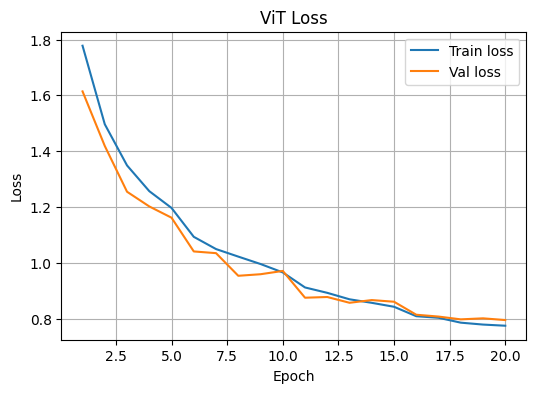

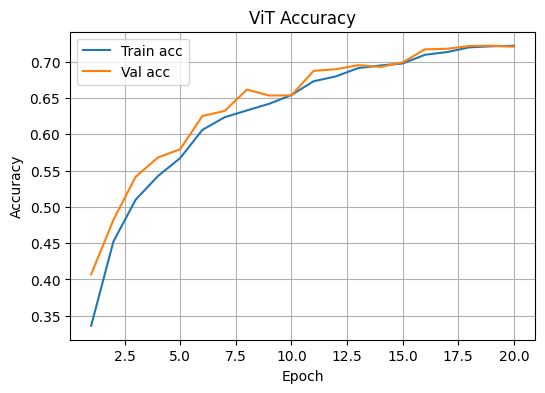

VisionTransformer(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(3, 192, kernel_size=(4, 4), stride=(4, 4))
  )
  (pos_dropout): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-5): 6 x ViTEncoderBlock(
      (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=192, out_features=192, bias=True)
      )
      (norm2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=192, out_features=384, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=384, out_features=192, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=192, out_features=10, bias=True)
)

In [5]:
# Train ViT on CIFAR-10

vit_model = VisionTransformer(
    img_size=32,
    patch_size=4,
    in_channels=3,
    num_classes=NUM_CLASSES,
    emb_dim=192,
    depth=6,
    num_heads=3,
    mlp_dim=384,
    dropout=0.1,
)

vit_best_state, vit_history, vit_train_time = train_model(
    vit_model,
    train_loader_vit,
    val_loader_vit,
    num_epochs=20,
    lr=3e-4,
    model_name="VisionTransformer",
    patience=4,
)

plot_history(vit_history, "ViT")
vit_model.load_state_dict(vit_best_state)
vit_model.to(device)

# **Evaluate ViT, Confusion Matrix, Visualization, Inference Benchmark**

ViT Test Loss: 0.8061, Test Accuracy: 71.59%, Eval time: 2.64s
Accuracy: 71.59%
Precision (macro): 71.90%
Recall (macro): 71.59%
F1-score (macro): 71.38%


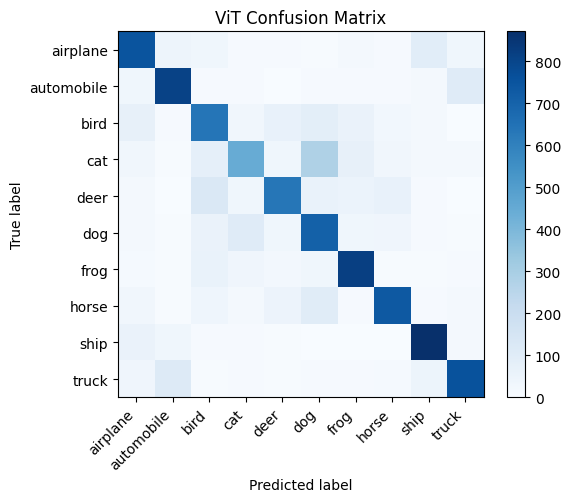

Sample predictions for ViT:


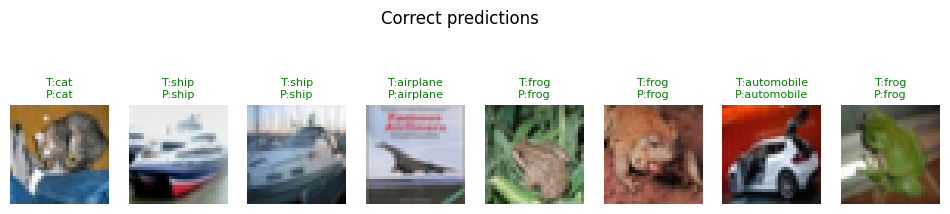

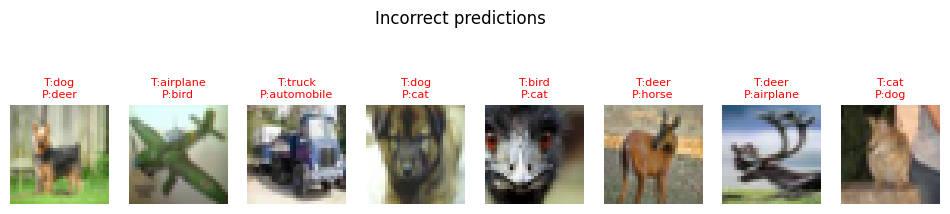

Inference over 30 batches took 1.11s, approx. +1.50 MB


In [6]:
# ViT evaluation and visualizations

criterion = nn.CrossEntropyLoss()
vit_test_loss, vit_test_acc, vit_test_time, vit_preds, vit_labels = evaluate(
    vit_model, test_loader_vit, criterion
)

print(f"ViT Test Loss: {vit_test_loss:.4f}, Test Accuracy: {vit_test_acc*100:.2f}%, Eval time: {vit_test_time:.2f}s")
vit_acc, vit_prec, vit_rec, vit_f1 = classification_report_and_confusion(
    vit_labels, vit_preds, cifar_classes, "ViT"
)

print("Sample predictions for ViT:")
show_sample_predictions(vit_model, test_loader_vit, cifar_classes)

vit_inf_time, vit_mem_used = benchmark_inference(vit_model, test_loader_vit, num_batches=30)

# **Hybrid CNN + MLP Architecture**

In [7]:
# Hybrid CNN + MLP model

class HybridCNNMLP(nn.Module):
    """
    Hybrid architecture: CNN for patch-like feature extraction, then MLP classifier.
    """
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.flatten_dim = 256 * 4 * 4
        self.mlp = nn.Sequential(
            nn.Linear(self.flatten_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        logits = self.mlp(x)
        return logits

# **Training Hybrid Model**


=== Training HybridCNNMLP ===
Epoch 01: train_loss=1.7618, val_loss=1.4478, train_acc=34.55%, val_acc=47.68%, train_time=18.0s, val_time=1.2s
  -> New best model saved.
Epoch 02: train_loss=1.4027, val_loss=1.1915, train_acc=49.02%, val_acc=57.06%, train_time=16.7s, val_time=2.3s
  -> New best model saved.
Epoch 03: train_loss=1.2042, val_loss=1.0140, train_acc=56.94%, val_acc=63.98%, train_time=19.7s, val_time=1.2s
  -> New best model saved.
Epoch 04: train_loss=1.0537, val_loss=0.8917, train_acc=62.35%, val_acc=67.92%, train_time=16.7s, val_time=1.2s
  -> New best model saved.
Epoch 05: train_loss=0.9437, val_loss=0.7948, train_acc=66.76%, val_acc=72.56%, train_time=17.5s, val_time=1.3s
  -> New best model saved.
Epoch 06: train_loss=0.8149, val_loss=0.7089, train_acc=71.51%, val_acc=75.02%, train_time=17.6s, val_time=1.2s
  -> New best model saved.
Epoch 07: train_loss=0.7629, val_loss=0.7015, train_acc=73.25%, val_acc=75.46%, train_time=17.6s, val_time=1.2s
  -> New best model sav

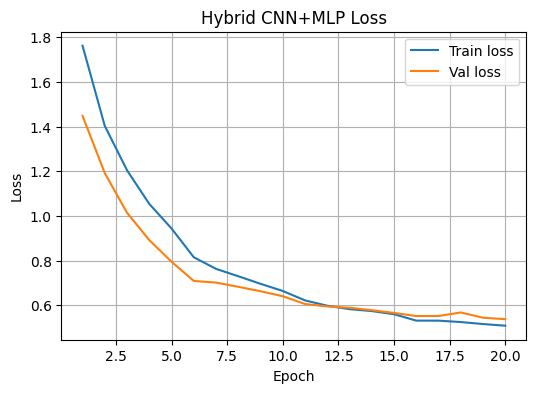

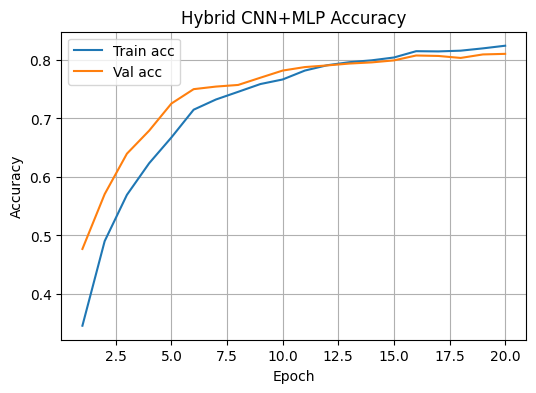

HybridCNNMLP(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (mlp): Sequential(
    (0): Linear(in_features=4096, out_features=512, bias=True)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512

In [8]:
# Train Hybrid CNN+MLP model

hybrid_model = HybridCNNMLP(num_classes=NUM_CLASSES)

hybrid_best_state, hybrid_history, hybrid_train_time = train_model(
    hybrid_model,
    train_loader_hybrid,
    val_loader_hybrid,
    num_epochs=20,
    lr=3e-4,
    model_name="HybridCNNMLP",
    patience=4,
)

plot_history(hybrid_history, "Hybrid CNN+MLP")
hybrid_model.load_state_dict(hybrid_best_state)
hybrid_model.to(device)

# **Evaluate Hybrid, Confusion Matrix, Visualization, Inference Benchmark**

Hybrid Test Loss: 0.5499, Test Accuracy: 81.43%, Eval time: 2.32s
Accuracy: 81.43%
Precision (macro): 81.46%
Recall (macro): 81.43%
F1-score (macro): 81.39%


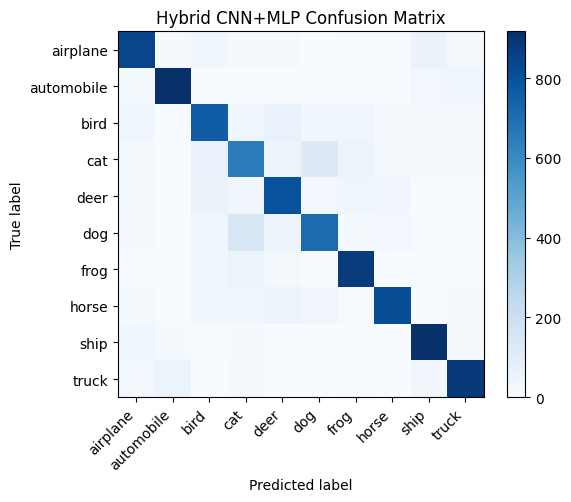

Sample predictions for Hybrid model:


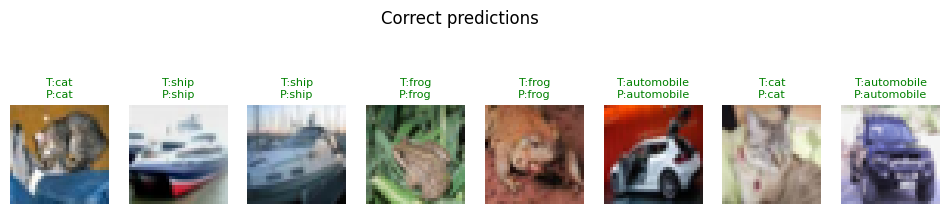

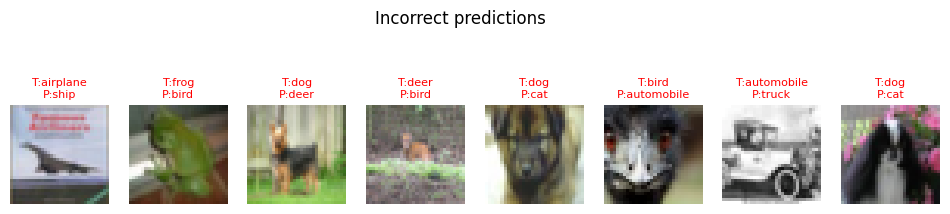

Inference over 30 batches took 1.19s, approx. +1.50 MB


In [9]:
# Hybrid CNN+MLP evaluation and visualizations

criterion = nn.CrossEntropyLoss()
hyb_test_loss, hyb_test_acc, hyb_test_time, hyb_preds, hyb_labels = evaluate(
    hybrid_model, test_loader_hybrid, criterion
)

print(f"Hybrid Test Loss: {hyb_test_loss:.4f}, Test Accuracy: {hyb_test_acc*100:.2f}%, Eval time: {hyb_test_time:.2f}s")
hyb_acc, hyb_prec, hyb_rec, hyb_f1 = classification_report_and_confusion(
    hyb_labels, hyb_preds, cifar_classes, "Hybrid CNN+MLP"
)

print("Sample predictions for Hybrid model:")
show_sample_predictions(hybrid_model, test_loader_hybrid, cifar_classes)

hyb_inf_time, hyb_mem_used = benchmark_inference(hybrid_model, test_loader_hybrid, num_batches=30)

# **Pretrained ResNet (Transfer Learning)**

In [10]:
# Pretrained ResNet18 with transfer learning

class ResNetTransfer(nn.Module):
    """
    ResNet18 transfer learning model for CIFAR-10.
    """
    def __init__(self, num_classes=10):
        super().__init__()
        base = resnet18(weights=resnet_weights)
        for param in base.parameters():
            param.requires_grad = False
        in_features = base.fc.in_features
        base.fc = nn.Linear(in_features, num_classes)
        self.model = base

    def forward(self, x):
        return self.model(x)

resnet_model = ResNetTransfer(num_classes=NUM_CLASSES)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 204MB/s]


# **Training ResNet Transfer Model**


=== Training ResNet18_Transfer ===
Epoch 01: train_loss=0.9111, val_loss=0.7067, train_acc=70.02%, val_acc=76.30%, train_time=99.3s, val_time=11.1s
  -> New best model saved.
Epoch 02: train_loss=0.6915, val_loss=0.6916, train_acc=76.15%, val_acc=76.48%, train_time=98.0s, val_time=11.2s
  -> New best model saved.
Epoch 03: train_loss=0.6641, val_loss=0.6531, train_acc=77.08%, val_acc=77.10%, train_time=98.7s, val_time=11.2s
  -> New best model saved.
Epoch 04: train_loss=0.6518, val_loss=0.6498, train_acc=77.33%, val_acc=77.68%, train_time=98.7s, val_time=11.3s
  -> New best model saved.
Epoch 05: train_loss=0.6402, val_loss=0.6634, train_acc=77.91%, val_acc=77.38%, train_time=97.6s, val_time=11.4s
Epoch 06: train_loss=0.6174, val_loss=0.6315, train_acc=78.45%, val_acc=78.32%, train_time=99.2s, val_time=11.2s
  -> New best model saved.
Epoch 07: train_loss=0.6120, val_loss=0.6333, train_acc=78.89%, val_acc=78.60%, train_time=98.9s, val_time=10.5s
Epoch 08: train_loss=0.6127, val_loss=

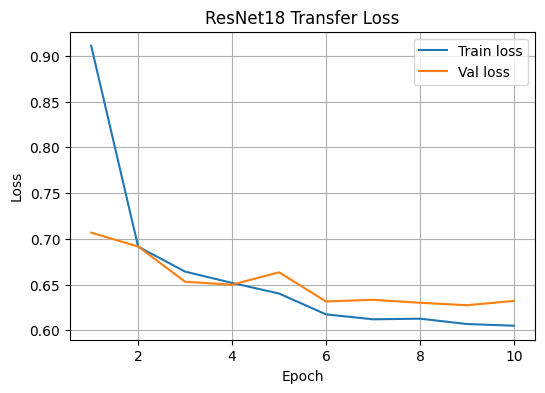

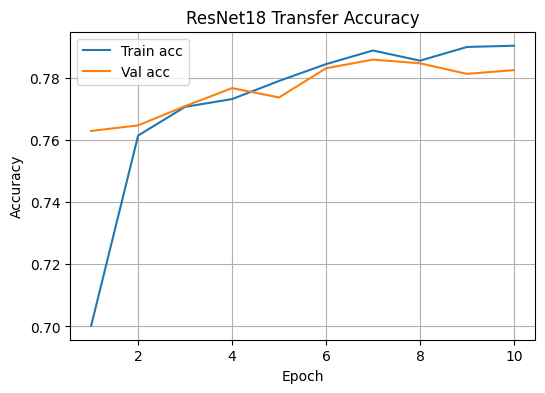

ResNetTransfer(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, trac

In [11]:
# Train ResNet transfer model

resnet_best_state, resnet_history, resnet_train_time = train_model(
    resnet_model,
    train_loader_resnet,
    val_loader_resnet,
    num_epochs=10,
    lr=1e-3,
    model_name="ResNet18_Transfer",
    patience=3,
)

plot_history(resnet_history, "ResNet18 Transfer")
resnet_model.load_state_dict(resnet_best_state)
resnet_model.to(device)

# **Evaluate ResNet, Confusion Matrix, Visualization, Inference Benchmark**

ResNet Test Loss: 0.6320, Test Accuracy: 78.26%, Eval time: 21.56s
Accuracy: 78.26%
Precision (macro): 78.41%
Recall (macro): 78.26%
F1-score (macro): 78.23%


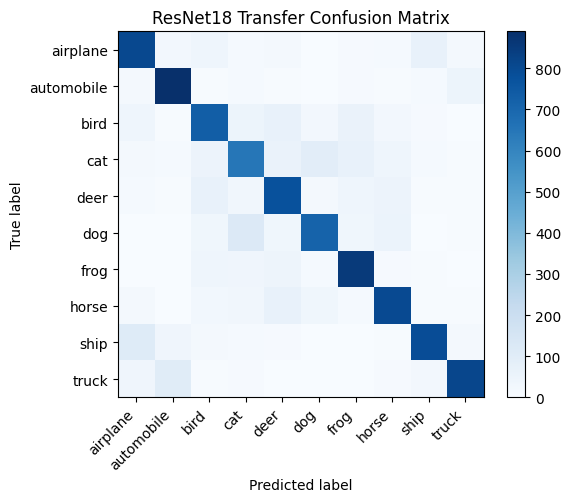

Sample predictions for ResNet model:


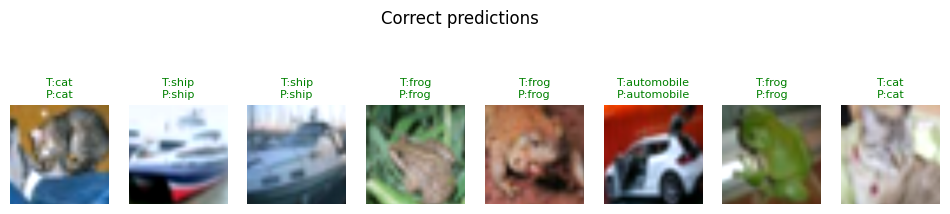

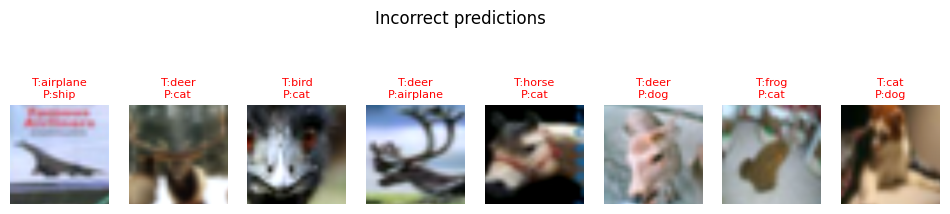

Inference over 30 batches took 4.90s, approx. +36.75 MB


In [12]:
# ResNet evaluation and visualizations

criterion = nn.CrossEntropyLoss()
res_test_loss, res_test_acc, res_test_time, res_preds, res_labels = evaluate(
    resnet_model, test_loader_resnet, criterion
)

print(f"ResNet Test Loss: {res_test_loss:.4f}, Test Accuracy: {res_test_acc*100:.2f}%, Eval time: {res_test_time:.2f}s")
res_acc, res_prec, res_rec, res_f1 = classification_report_and_confusion(
    res_labels, res_preds, cifar_classes, "ResNet18 Transfer"
)

print("Sample predictions for ResNet model:")
show_sample_predictions(resnet_model, test_loader_resnet, cifar_classes)

res_inf_time, res_mem_used = benchmark_inference(resnet_model, test_loader_resnet, num_batches=30)

# **Final Comparison Visualization of all three Model**

In [13]:
# Compare ViT, Hybrid, and ResNet models

print("=== Summary Metrics ===")
print(f"{'Model':<15} {'Acc%':>8} {'Prec%':>8} {'Rec%':>8} {'F1%':>8} "
      f"{'TrainTime(s)':>14} {'InfTime(s)':>12} {'Mem(MB)':>10}")
print("-" * 90)
print(f"{'ViT':<15} {vit_acc*100:8.2f} {vit_prec*100:8.2f} {vit_rec*100:8.2f} {vit_f1*100:8.2f} "
      f"{vit_train_time:14.1f} {vit_inf_time:12.2f} {vit_mem_used:10.2f}")
print(f"{'Hybrid':<15} {hyb_acc*100:8.2f} {hyb_prec*100:8.2f} {hyb_rec*100:8.2f} {hyb_f1*100:8.2f} "
      f"{hybrid_train_time:14.1f} {hyb_inf_time:12.2f} {hyb_mem_used:10.2f}")
print(f"{'ResNet':<15} {res_acc*100:8.2f} {res_prec*100:8.2f} {res_rec*100:8.2f} {res_f1*100:8.2f} "
      f"{resnet_train_time:14.1f} {res_inf_time:12.2f} {res_mem_used:10.2f}")

=== Summary Metrics ===
Model               Acc%    Prec%     Rec%      F1%   TrainTime(s)   InfTime(s)    Mem(MB)
------------------------------------------------------------------------------------------
ViT                71.59    71.90    71.59    71.38          463.4         1.11       1.50
Hybrid             81.43    81.46    81.43    81.39          341.1         1.19       1.50
ResNet             78.26    78.41    78.26    78.23          985.2         4.90      36.75


# **Metrics Comparison and Bar Plots**

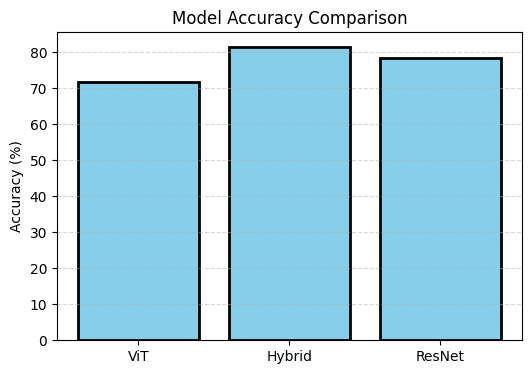

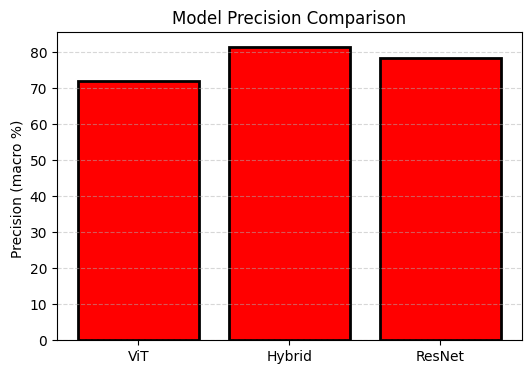

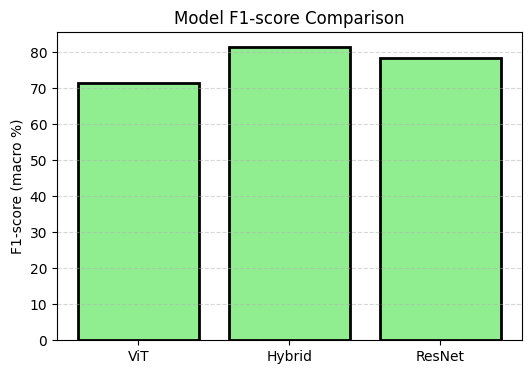

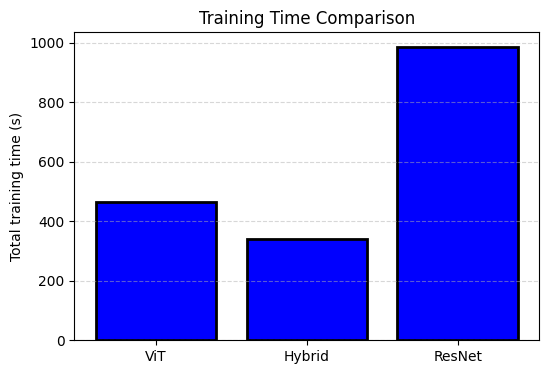

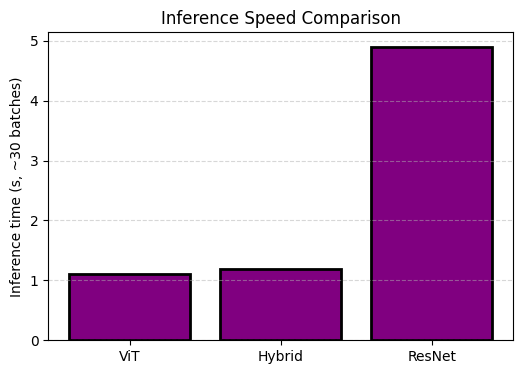

In [14]:
models = ["ViT", "Hybrid", "ResNet"]

acc_values = [vit_acc, hyb_acc, res_acc]
prec_values = [vit_prec, hyb_prec, res_prec]
rec_values = [vit_rec, hyb_rec, res_rec]
f1_values = [vit_f1, hyb_f1, res_f1]
train_times = [vit_train_time, hybrid_train_time, resnet_train_time]
inf_times = [vit_inf_time, hyb_inf_time, res_inf_time]

plt.figure(figsize=(6, 4))
plt.bar(models, [a*100 for a in acc_values], color="skyblue", edgecolor='black', linewidth=2)
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.savefig('accuracy_comparison.png', dpi=300)
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(models, [p*100 for p in prec_values], color="red", edgecolor='black', linewidth=2)
plt.ylabel("Precision (macro %) ")
plt.title("Model Precision Comparison")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.savefig('precicion_comparison.png', dpi=300)
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(models, [f*100 for f in f1_values], color="lightgreen", edgecolor='black', linewidth=2)
plt.ylabel("F1-score (macro %)")
plt.title("Model F1-score Comparison")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.savefig('f1_comparison.png', dpi=300)
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(models, train_times, color="blue", edgecolor='black', linewidth=2)
plt.ylabel("Total training time (s)")
plt.title("Training Time Comparison")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.savefig('training_time_comparison.png', dpi=300)
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(models, inf_times, color="purple", edgecolor='black', linewidth=2)
plt.ylabel("Inference time (s, ~30 batches)")
plt.title("Inference Speed Comparison")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.savefig('inference_speed_comparison.png', dpi=300)
plt.show()